In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

In [3]:
with open('/Users/anshgrover/AIDA3/PINN-tutorial/data/massdamper_data.pkl', 'rb') as f:
    data = pickle.load(f)

model_name = 'No external force'
sparsity   = 'sparsity 1.667Hz'

obs   = data['data_sampled_random_with_noise'][model_name][sparsity]
t_obs = np.array(obs['t'])
y_obs = np.array(obs['x'])

n = len(t_obs)
print(f"n = {n}")
print(f"t range: [{t_obs[0]:.2f}, {t_obs[-1]:.2f}]")

n = 100
t range: [0.00, 60.00]


In [4]:
m_true = 2.0
c_true = 0.3
k_true = 0.2
delta_true  = c_true / (2 * m_true)
omega0_true = np.sqrt(k_true / m_true)

print(f"true delta  = {delta_true:.4f}")
print(f"true omega0 = {omega0_true:.4f}")

def mass_damper(delta, omega0, t):
    omega = np.sqrt(omega0**2 - delta**2)
    phi = np.arctan(-delta/omega)
    A = 1/(2*np.cos(phi))
    return np.exp(-delta*t) * 2*A*np.cos(phi + omega*t)

y_exact = mass_damper(delta_true, omega0_true, t_obs)

true delta  = 0.0750
true omega0 = 0.3162


In [5]:
X = t_obs.reshape(-1, 1)
y = y_exact

X_train = t_obs.reshape(-1, 1)
y_train_noisy = y_obs

noise_std = 0.1

kernel = 1.0 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
gaussian_process = GaussianProcessRegressor(
    kernel=kernel, alpha=noise_std**2, n_restarts_optimizer=9
)
gaussian_process.fit(X_train, y_train_noisy)
mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)

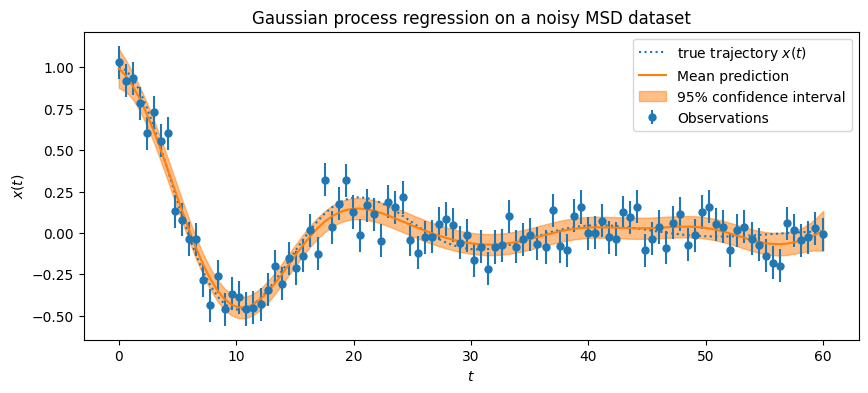

Fitted kernel: 0.425**2 * RBF(length_scale=6.34)


In [6]:
plt.figure(figsize=(10, 4))
plt.plot(X, y, label=r"true trajectory $x(t)$", linestyle="dotted")
plt.errorbar(
    X_train,
    y_train_noisy,
    noise_std,
    linestyle="None",
    color="tab:blue",
    marker=".",
    markersize=10,
    label="Observations",
)
plt.plot(X, mean_prediction, label="Mean prediction")
plt.fill_between(
    X.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    color="tab:orange",
    alpha=0.5,
    label=r"95% confidence interval",
)
plt.legend()
plt.xlabel("$t$")
plt.ylabel("$x(t)$")
_ = plt.title("Gaussian process regression on a noisy MSD dataset")
plt.show()

print(f"Fitted kernel: {gaussian_process.kernel_}")